# Validating Multiple Linear Regression From Scratch

This notebook validates the custom Multiple Linear Regression
implementation against scikit-learn's LinearRegression model.

The custom model uses the Ordinary Least Squares (OLS)
closed-form solution.

In [4]:
import numpy as np
import pandas as pd

from pathlib import Path
import sys

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Get into the root of the project and then we can access src module
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.linear_regression import MultipleLinearRegression
from src.metrics import mae, mse, rmse, r2_score

In [5]:
df = pd.read_csv("../data/Advertising.csv")

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
custom_model = MultipleLinearRegression()

custom_model.fit(X_train, y_train)

custom_predictions = custom_model.predict(X_test)

In [8]:
sklearn_model = LinearRegression()

sklearn_model.fit(X_train, y_train)

sklearn_predictions = sklearn_model.predict(X_test)

In [9]:
comparison = pd.DataFrame({
    "Feature": ["Intercept", "TV", "Radio", "Newspaper"],
    "From Scratch": [custom_model.intercept_, *custom_model.coef_],
    "sklearn": [sklearn_model.intercept_, *sklearn_model.coef_]
})

comparison

,Feature,From Scratch,sklearn
0,Intercept,2.979067,2.979067
1,TV,0.044730,0.044730
2,Radio,0.189195,0.189195
3,Newspaper,0.002761,0.002761


In [11]:
# The difference between coeffients and intercepts of both the models are very very low close to zero
coefficient_difference = np.array([custom_model.intercept_, *custom_model.coef_]) - np.array([sklearn_model.intercept_, *sklearn_model.coef_])

coefficient_difference

array([ 7.63833441e-14, -2.63677968e-16, -1.66533454e-16, -7.74987713e-16])

In [14]:
# Here we have checked that if two of the models coeffient and intercept are close or not
# and it comes out to be True it means that both models have the same coefficients and intercept
np.allclose([custom_model.intercept_, *custom_model.coef_], [sklearn_model.intercept_, *sklearn_model.coef_])

True

In [15]:
prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "From Scratch": custom_predictions,
    "sklearn": sklearn_predictions
})

prediction_comparison.head(10)

,Actual,From Scratch,sklearn
0,16.9,16.408024,16.408024
1,22.4,20.889882,20.889882
2,21.4,21.553843,21.553843
3,7.3,10.608503,10.608503
4,24.7,22.112373,22.112373
5,12.6,13.105592,13.105592
6,22.3,21.057192,21.057192
7,8.4,7.461010,7.461010
8,11.5,13.606346,13.606346
9,14.9,15.155070,15.155070


In [16]:
prediction_difference = custom_predictions - sklearn_predictions

print("Maximum absolute difference:", np.max(np.abs(prediction_difference)))

Maximum absolute difference: 6.750155989720952e-14


In [17]:
metrics_comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "From Scratch": [
        mae(y_test, custom_predictions),
        mse(y_test, custom_predictions),
        rmse(y_test, custom_predictions),
        r2_score(y_test, custom_predictions)
    ],
    "sklearn": [
        mae(y_test, sklearn_predictions),
        mse(y_test, sklearn_predictions),
        rmse(y_test, sklearn_predictions),
        sklearn_model.score(X_test, y_test)
    ]
})

metrics_comparison

,Metric,From Scratch,sklearn
0,MAE,1.460757,1.460757
1,MSE,3.174097,3.174097
2,RMSE,1.781600,1.781600
3,R²,0.899438,0.899438


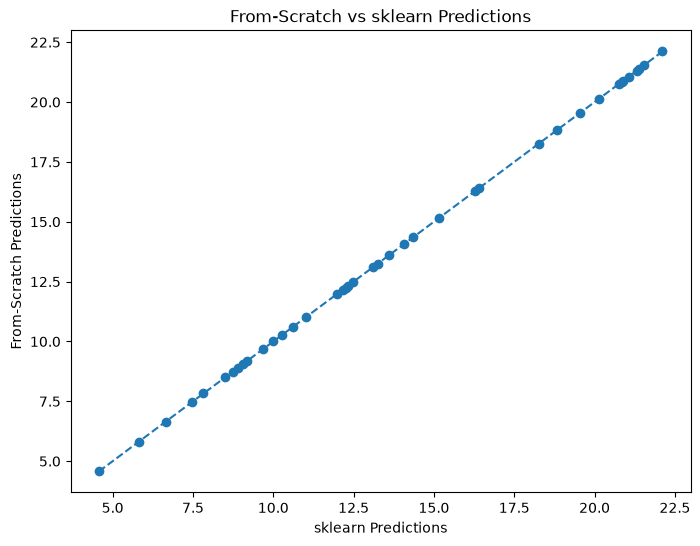

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    sklearn_predictions,
    custom_predictions
)

min_value = min(
    sklearn_predictions.min(),
    custom_predictions.min()
)

max_value = max(
    sklearn_predictions.max(),
    custom_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("sklearn Predictions")
plt.ylabel("From-Scratch Predictions")

plt.title("From-Scratch vs sklearn Predictions")

plt.show()

## Conclusion

The Multiple Linear Regression implementation developed from
scratch using the OLS closed-form solution produces coefficients,
predictions, and evaluation metrics that closely match the
scikit-learn implementation.

This validates the mathematical implementation of the custom
OLS-based regression model.